Loading the data processed by hdWGCNA in R

In [1]:
import math
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [2]:
# Selecting the brain region
select_region = "Microglia"

In [3]:
# Loading AnnData object
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / f"WMB-10Xv3-{select_region}-raw-wmeta.h5ad"
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 81472 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color', 'batch'
    var: 'gene_symbol'

In [4]:
# Loading Module Eigengenes dataframe
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs")
modules_df = pd.read_csv(base_path / f"WMB-10Xv3-{select_region}-raw-mc-wgcna-modules.csv", index_col="Unnamed: 0")
modules_df.head()

,gene_name,module,color,kME_MG-M1,kME_grey,kME_MG-M2,kME_MG-M3,kME_MG-M4,kME_MG-M5
ENSMUSG00000004296,ENSMUSG00000004296,MG-M1,turquoise,0.067324,-0.005248,0.069128,-0.008137,0.007815,-0.031117
ENSMUSG00000002985,ENSMUSG00000002985,MG-M1,turquoise,0.189944,0.147565,0.190743,0.233783,0.050853,-0.158240
ENSMUSG00000039109,ENSMUSG00000039109,grey,grey,0.001604,0.012000,0.142080,0.001089,0.063053,0.013650
ENSMUSG00000015568,ENSMUSG00000015568,MG-M2,brown,0.067394,0.009954,0.541998,-0.002288,0.017932,-0.027402
ENSMUSG00000020914,ENSMUSG00000020914,grey,grey,0.018736,-0.008138,0.052446,-0.005465,0.032833,0.016444


In [5]:
# Loading Module Eigengenes dataframe
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs")
MEs_df = pd.read_csv(base_path / f"WMB-10Xv3-{select_region}-raw-mc-wgcna-MEs.csv", index_col="Unnamed: 0")
MEs_df = MEs_df.drop(columns=["grey"])
MEs_df.head()

,blue,green,yellow,turquoise,brown
TGGATCAGTAACACCT-478_A02-0,3.520289,-0.434925,-1.310789,1.821404,0.717890
TCACTCGCAAGTTCGT-215_C01-0,-0.486307,-1.138845,-0.099216,-8.427007,-0.556104
GAGTGAGTCCTTATCA-472_B05-0,-3.545015,0.821186,-1.042361,11.035446,5.529251
CACGGGTTCATTTCCA-216_D01-0,2.866931,-1.964552,0.176167,-7.483160,-0.035609
TTTCACATCCGCACTT-171_C01-0,-1.317700,-2.456663,-0.528557,2.435767,1.356410


In [6]:
# Create a mapping from color to module
color_to_module = modules_df.set_index("color")["module"].to_dict()

# Rename the columns of MEs_df
MEs_df.rename(columns=color_to_module, inplace=True)

# Sort the columns of MEs_df alphabetically
MEs_df = MEs_df.reindex(sorted(MEs_df.columns), axis=1)
MEs_df.head()

,MG-M1,MG-M2,MG-M3,MG-M4,MG-M5
TGGATCAGTAACACCT-478_A02-0,1.821404,0.717890,-0.434925,-1.310789,3.520289
TCACTCGCAAGTTCGT-215_C01-0,-8.427007,-0.556104,-1.138845,-0.099216,-0.486307
GAGTGAGTCCTTATCA-472_B05-0,11.035446,5.529251,0.821186,-1.042361,-3.545015
CACGGGTTCATTTCCA-216_D01-0,-7.483160,-0.035609,-1.964552,0.176167,2.866931
TTTCACATCCGCACTT-171_C01-0,2.435767,1.356410,-2.456663,-0.528557,-1.317700


In [7]:
# Getting the list of modules
modules = MEs_df.columns.tolist()

In [8]:
# Adding MEs to AnnData object
merged_df = pd.merge(adata.obs, MEs_df, left_index=True, right_index=True)
merged_df.head()

,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,entity,brain_section_label,library_method,region_of_interest_acronym,donor_label,donor_genotype,...,supertype_color,cluster_color,region_of_interest_order,region_of_interest_color,batch,MG-M1,MG-M2,MG-M3,MG-M4,MG-M5
TGGATCAGTAACACCT-478_A02-0,TGGATCAGTAACACCT,478_A02,L8TX_210107_02_H11,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Snap25-IRES2-Cre;Ai14-556943,Ai14(RCL-tdT)/wt,...,#62CC3D,#651FCC,28,#CC0026,0,1.821404,0.717890,-0.434925,-1.310789,3.520289
TCACTCGCAAGTTCGT-215_C01-0,TCACTCGCAAGTTCGT,215_C01,L8TX_200206_01_D03,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Slc32a1-IRES-Cre;Ai14-507771,Slc32a1-IRES-Cre/wt;Ai14(RCL-tdT)/wt,...,#62CC3D,#651FCC,28,#CC0026,0,-8.427007,-0.556104,-1.138845,-0.099216,-0.486307
GAGTGAGTCCTTATCA-472_B05-0,GAGTGAGTCCTTATCA,472_B05,L8TX_201217_01_H07,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Snap25-IRES2-Cre;Ai14-557213,Ai14(RCL-tdT)/wt,...,#62CC3D,#651FCC,28,#CC0026,0,11.035446,5.529251,0.821186,-1.042361,-3.545015
CACGGGTTCATTTCCA-216_D01-0,CACGGGTTCATTTCCA,216_D01,L8TX_200206_01_A04,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Slc32a1-IRES-Cre;Ai14-507773,Slc32a1-IRES-Cre/wt;Ai14(RCL-tdT)/wt,...,#62CC3D,#651FCC,28,#CC0026,0,-7.483160,-0.035609,-1.964552,0.176167,2.866931
TTTCACATCCGCACTT-171_C01-0,TTTCACATCCGCACTT,171_C01,L8TX_191029_01_E08,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Snap25-IRES2-Cre;Ai14-493659,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#62CC3D,#651FCC,28,#CC0026,0,2.435767,1.356410,-2.456663,-0.528557,-1.317700


## Cell labels

In [9]:
from matplotlib.lines import Line2D

def plot_labels(xx, yy, cc=None, val=None, label_column=None, fig_width=6, fig_height=6, cmap=None):
    # Initialize plot with constrained layout to prevent overlap
    fig, ax = plt.subplots(constrained_layout=True)
    fig.set_size_inches(fig_width, fig_height)
    
    # Plot the data
    if cmap is not None:
        scatter = ax.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
    elif cc is not None:
        scatter = ax.scatter(xx, yy, s=0.5, color=cc, marker='.')
    else:
        scatter = ax.scatter(xx, yy, s=0.5, marker='.')
    
    # Set axis properties
    ax.axis('equal')
    # ax.set_xlim(-18, 27)
    # ax.set_ylim(-18, 27)
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Add legend if label_column is provided
    if label_column is not None:
        # Create DataFrame for unique label-color pairs
        df_legend = pd.DataFrame({'label': label_column, 'color': cc}).drop_duplicates().sort_values('label')
        
        # Create legend handles
        legend_elements = [
            Line2D([0], [0], 
                   marker='o', 
                   color='w', 
                   label=row['label'],
                   markerfacecolor=row['color'], 
                   markersize=8)
            for _, row in df_legend.iterrows()
        ]
        
        # Add legend outside the plot (adjust bbox_to_anchor as needed)
        ax.legend(
            handles=legend_elements, 
            title="Legend", 
            loc="upper left",  # Anchor point for the legend
            bbox_to_anchor=(1.05, 1)  # Shift legend to the right of the plot
        )
    
    return fig, ax

(<Figure size 600x600 with 1 Axes>, <Axes: >)

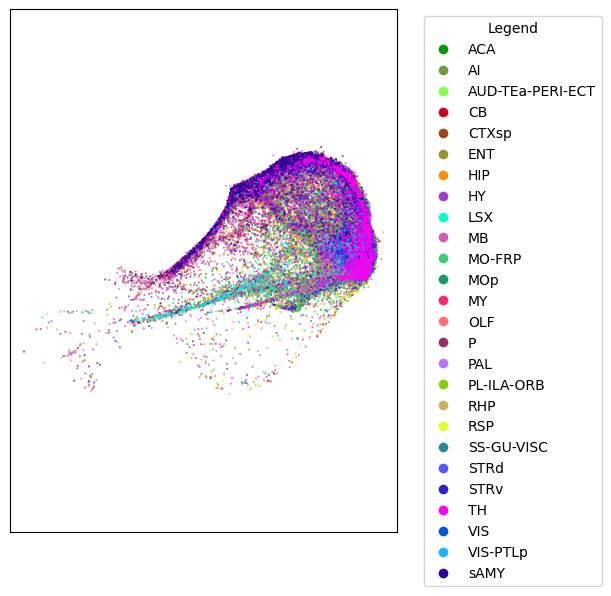

In [10]:
plot_labels(adata.obs['x'], adata.obs['y'], cc=adata.obs['region_of_interest_color'], label_column=adata.obs['region_of_interest_acronym'])

## Module Eigengene activation in UMAP

In [11]:
def plot_umap(data, x_col="x", y_col="y", color_col="turquoise", fig_width=4, fig_height=4, cmap="viridis"):
    """
    Plots a UMAP visualization with a style similar to a minimal scatter plot.

    Parameters:
        data (pd.DataFrame): The dataframe containing UMAP coordinates and the column to color.
        x_col (str): Column name for the x-axis UMAP coordinate.
        y_col (str): Column name for the y-axis UMAP coordinate.
        color_col (str): Column name for the color values.
        fig_width (float): Width of the figure.
        fig_height (float): Height of the figure.
        cmap (str): Colormap for the scatter plot.

    Returns:
        fig, ax: Matplotlib figure and axis objects.
    """
    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)

    # Scatter plot with small marker size
    scatter = ax.scatter(
        data[x_col],
        data[y_col],
        s=0.5,
        c=data[color_col],
        cmap=cmap,
        marker='.',
        edgecolor='none'
    )

    # Set equal axis aspect ratio
    ax.axis('equal')
    ax.set_xticks([])
    ax.set_yticks([])

    # Add a colorbar
    fig.colorbar(scatter, ax=ax, orientation='vertical', label=color_col)

    return fig, ax

(<Figure size 400x400 with 2 Axes>, <Axes: >)

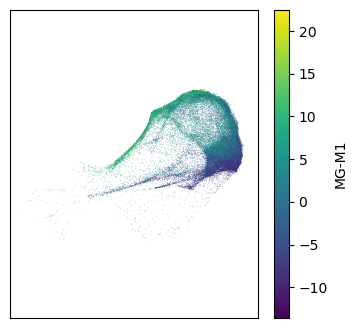

In [12]:
plot_umap(merged_df, color_col="MG-M1")

In [13]:
def plot_multiple_umaps(data, modules, x_col="x", y_col="y", fig_width=4, fig_height=4, cmap="viridis"):
    """
    Plots multiple UMAP visualizations for the specified modules.

    Parameters:
        data (pd.DataFrame): The dataframe containing UMAP coordinates and the module eigengenes.
        modules (list): List of module names to plot.
        x_col (str): Column name for the x-axis UMAP coordinate.
        y_col (str): Column name for the y-axis UMAP coordinate.
        fig_width (float): Width of each subplot.
        fig_height (float): Height of each subplot.
        cmap (str): Colormap for the scatter plots.

    Returns:
        None
    """
    n_cols = 3  # Number of columns for subplots
    n_rows = math.ceil(len(modules) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width * n_cols, fig_height * n_rows))
    axes = axes.flatten()

    for i, module in enumerate(modules):
        ax = axes[i]
        scatter = ax.scatter(
            data[x_col],
            data[y_col],
            s=0.5,
            c=data[module],
            cmap=cmap,
            marker='.',
            edgecolor='none'
        )

        ax.axis('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(module)

        fig.colorbar(scatter, ax=ax, orientation='vertical', label=module)

    # Turn off unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

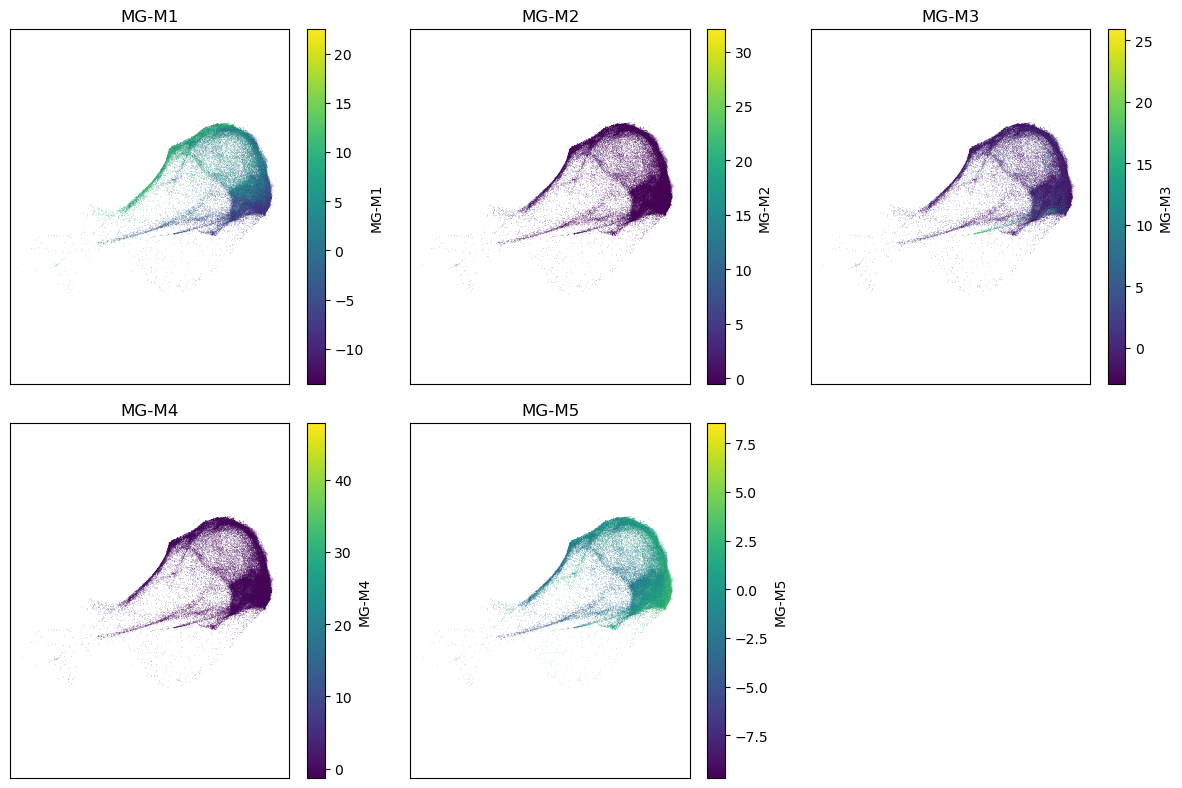

In [14]:
plot_multiple_umaps(merged_df, modules)

In [15]:
def plot_multiple_umaps_renamed(data, modules, module_names=None, x_col="x", y_col="y", fig_width=4, fig_height=4, cmap="viridis", title=None):
    """
    Plots multiple UMAP visualizations for the specified modules with optional new names and a figure title.

    Parameters:
        data (pd.DataFrame): The dataframe containing UMAP coordinates and the module eigengenes.
        modules (list): List of module names to plot.
        module_names (dict): Optional dictionary mapping old module names to new names for labeling.
        x_col (str): Column name for the x-axis UMAP coordinate.
        y_col (str): Column name for the y-axis UMAP coordinate.
        fig_width (float): Width of each subplot.
        fig_height (float): Height of each subplot.
        cmap (str): Colormap for the scatter plots.
        title (str): Title for the entire figure.

    Returns:
        None
    """
    n_cols = 3  # Number of columns for subplots
    n_rows = math.ceil(len(modules) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width * n_cols, fig_height * n_rows))
    axes = axes.flatten()

    for i, module in enumerate(modules):
        ax = axes[i]
        scatter = ax.scatter(
            data[x_col],
            data[y_col],
            s=0.5,
            c=data[module],
            cmap=cmap,
            marker='.',
            edgecolor='none'
        )

        ax.axis('equal')
        ax.set_xticks([])
        ax.set_yticks([])

        # Use new name if provided, otherwise use the original module name
        title_text = module_names[module] if module_names and module in module_names else module
        ax.set_title(title_text)

        fig.colorbar(scatter, ax=ax, orientation='vertical', label=title_text)

    # Turn off unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Add a title to the entire figure if provided
    if title:
        fig.suptitle(title, fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make space for the title
    plt.show()

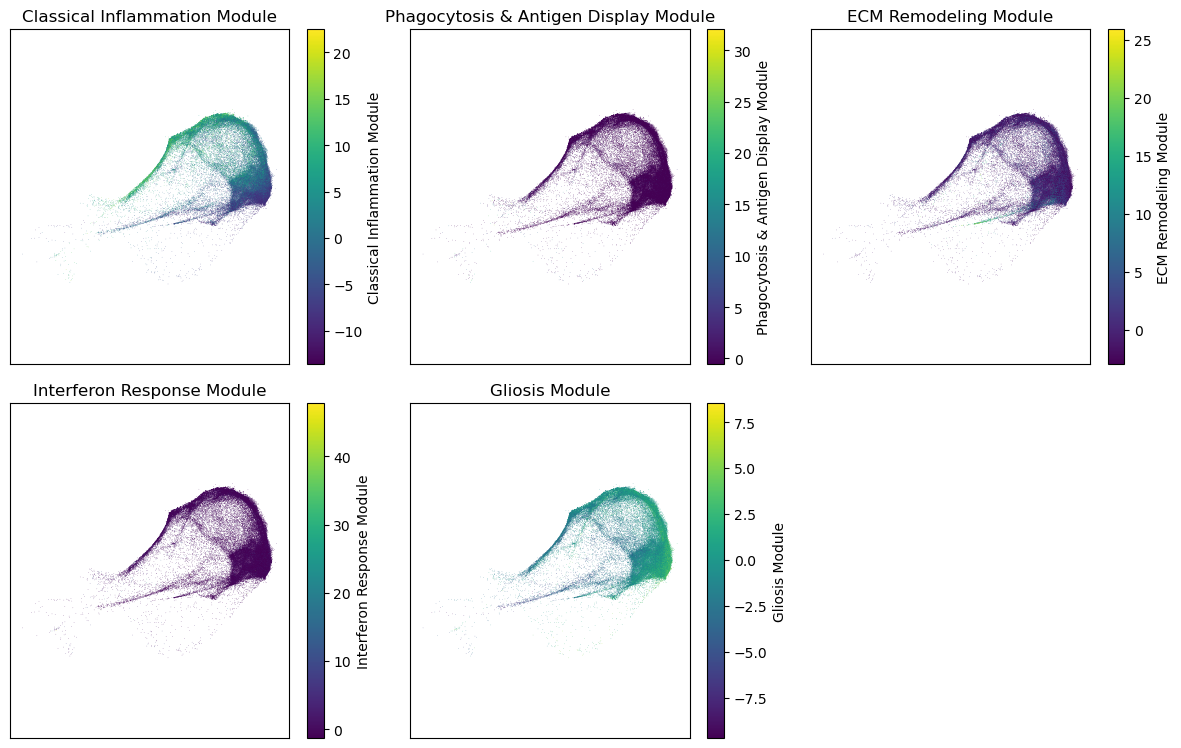

In [16]:
# output_file = "/home/momo/Pictures/ABCA/Isocortex_ME_UMAP.svg"
module_names = {
    "MG-M1": "Classical Inflammation Module",
    "MG-M2": "Phagocytosis & Antigen Display Module",
    "MG-M3": "ECM Remodeling Module",
    "MG-M4": "Interferon Response Module",
    "MG-M5": "Gliosis Module"
}
plot_multiple_umaps_renamed(merged_df, modules, module_names)

## Module Eigengenes across cell classes

In [21]:
# Convert to AnnData (required for scanpy plotting)
adata_vis = sc.AnnData(merged_df[modules])
adata_vis.obs["region_of_interest_acronym"] = merged_df["region_of_interest_acronym"]  # Add cell type labels

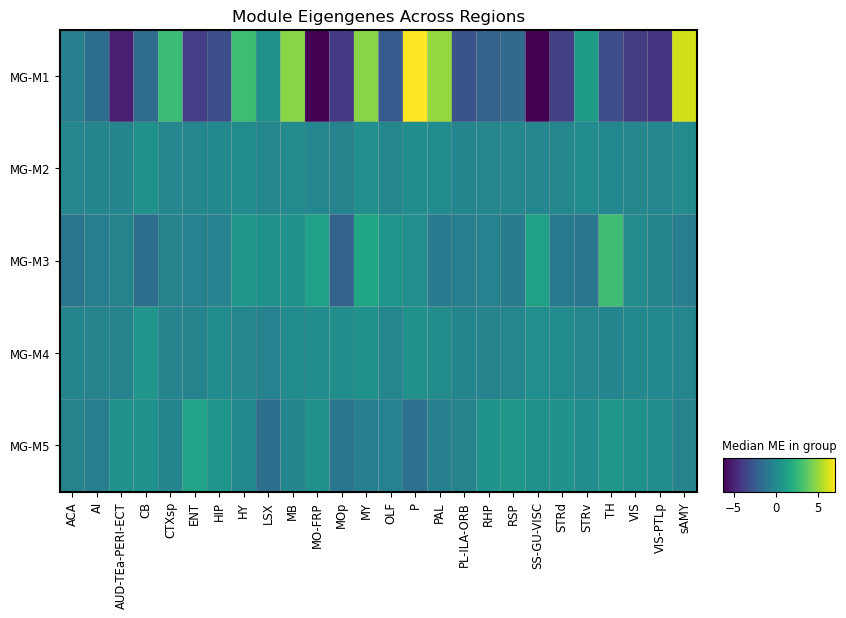

In [22]:
# Matrixplot
sc.pl.matrixplot(
    adata_vis,
    var_names=modules,
    groupby="region_of_interest_acronym",
    swap_axes=True,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 6),  # Adjust size as needed
    title="Module Eigengenes Across Regions",
    colorbar_title="Median ME in group",
    cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    use_raw=False,
)

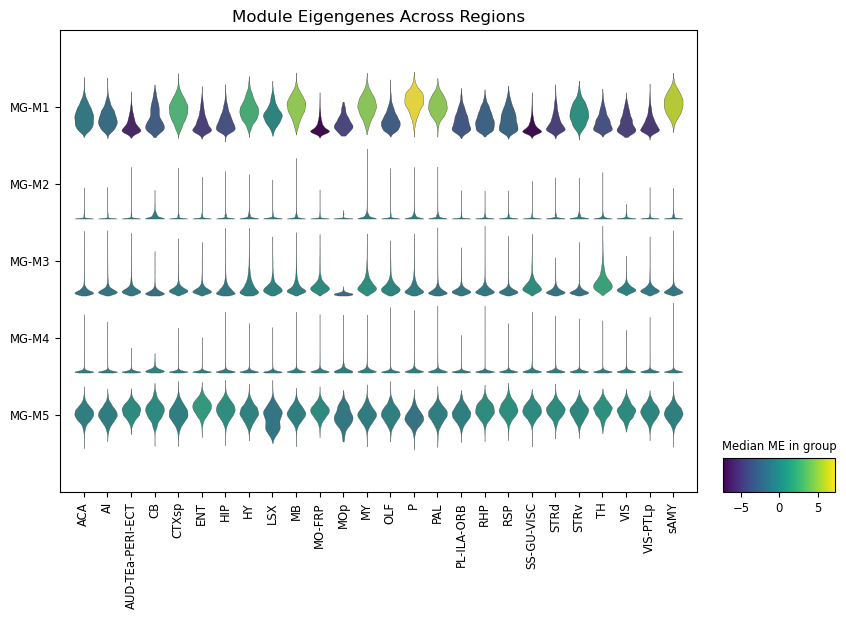

In [23]:
# Plot stacked violins
sc.pl.stacked_violin(
    adata_vis,
    var_names=modules,
    groupby="region_of_interest_acronym",
    swap_axes=True,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 6),  # Adjust size as needed
    title="Module Eigengenes Across Regions",
    colorbar_title="Median ME in group",
    cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    use_raw=False,
)

# Quantifying module specificity

In [24]:
tau_scores = {}

for module in modules:
    tau_df = merged_df[["region_of_interest_acronym", module]].copy()
    tau_df[module] = tau_df[module] - tau_df[module].min() + 1e-6  # Shift the eigengene values to ensure non-negativity

    # Compute average eigengene per cell class
    avg_expression = tau_df.groupby('region_of_interest_acronym', observed=False)[module].mean()

    # Normalize by the maximum average expression
    max_expr = avg_expression.max()
    normalized_expr = avg_expression / max_expr

    # Compute tau score
    tau = np.sum(1 - normalized_expr) / (len(normalized_expr) - 1)
    tau_scores[module] = tau

# Print Tau scores for all modules
for module, score in tau_scores.items():
    print(f"Tau specificity score for {module} module: {score:.3f}")

Tau specificity score for MG-M1 module: 0.396
Tau specificity score for MG-M2 module: 0.477
Tau specificity score for MG-M3 module: 0.531
Tau specificity score for MG-M4 module: 0.355
Tau specificity score for MG-M5 module: 0.132
